In [ ]:
from pathlib import Path
import sys
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

# Add parent directory to path for imports
sys.path.insert(0, str(Path('..').resolve()))

from agents import ZeroShotAgent, SingleShotAgent, DirectEditAgent
from lib.render import render_image
from lib.types import Spec

In [3]:
# Load canva specs directory
specs_dir = Path('../datasets/specs/')

# Get all spec directories
spec_paths = sorted(list(specs_dir.glob('*/spec.json')))

# Create dataframe
specs_df = pd.DataFrame({
    'template_id': [p.parent.name for p in spec_paths],
    'spec_path': spec_paths
})

print(f"Found {len(specs_df)} design specs")
specs_df.head()

Found 51 design specs


,template_id,spec_path
0,1131w-02GXIIidf_4,../datasets/specs/1131w-02GXIIidf_4/spec...
1,1131w-50t2MzJLmsM,../datasets/specs/1131w-50t2MzJLmsM/spec...
2,1131w-9cN5biKALLQ,../datasets/specs/1131w-9cN5biKALLQ/spec...
3,1131w-Cn6h5Tqrn10,../datasets/specs/1131w-Cn6h5Tqrn10/spec...
4,1131w-DBVzDPV0y5E,../datasets/specs/1131w-DBVzDPV0y5E/spec...


In [4]:
# Test configuration
TEST_SIZE = 5
EDIT_INSTRUCTION = "make it more dream-like"
OUTPUT_ROOT = Path('../datasets/edits')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Select first N specs for testing
test_specs = specs_df.head(TEST_SIZE).copy()

print(f"Testing on {len(test_specs)} designs")
print(f"Instruction: '{EDIT_INSTRUCTION}'")
print(f"Output directory: {OUTPUT_ROOT}")
print()
print("Test designs:")
for tid in test_specs['template_id']:
    print(f"  - {tid}")

Testing on 5 designs
Instruction: 'make it more dream-like'
Output directory: ../datasets/edits

Test designs:
  - 1131w-02GXIIidf_4
  - 1131w-50t2MzJLmsM
  - 1131w-9cN5biKALLQ
  - 1131w-Cn6h5Tqrn10
  - 1131w-DBVzDPV0y5E


In [ ]:
# Initialize agents
agents = {
    'zeroshot': ZeroShotAgent(verbose=False),
    'singleshot': SingleShotAgent(verbose=False),
    'direct_edit': DirectEditAgent(verbose=False),
    # Add more agents here as they're implemented:
    # 'vqa_critic': VQACriticAgent(verbose=False),
}

print(f"Initialized {len(agents)} agent(s):")
for agent_slug in agents:
    print(f"  - {agent_slug}")

In [ ]:
# Run all edits in parallel
results = []

def apply_edit(template_id: str, spec_path: Path, agent_slug: str, agent) -> dict:
    """Apply a single edit and return result info."""
    output_dir = OUTPUT_ROOT / f"{template_id}-{agent_slug}"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_spec_path = output_dir / 'spec.json'
    output_render_path = output_dir / 'render.png'
    
    try:
        # Apply the edit
        result_path = agent.edit(
            spec_path=spec_path,
            instruction=EDIT_INSTRUCTION,
            output_path=output_spec_path
        )
        
        # Copy assets from original spec directory if they exist
        import shutil
        source_dir = spec_path.parent
        if source_dir.exists():
            # Copy all asset-*.png files
            for asset_file in source_dir.glob('asset-*.png'):
                shutil.copy2(asset_file, output_dir / asset_file.name)
            # Copy background.png if exists
            bg_file = source_dir / 'background.png'
            if bg_file.exists():
                shutil.copy2(bg_file, output_dir / 'background.png')
        
        # Render the edited spec
        with open(result_path, 'r') as f:
            import json
            spec_dict = json.load(f)
        
        spec = Spec(**spec_dict)
        render_image(
            spec=spec,
            output_path=output_render_path,
            canvas_width=spec.canvas_width,
            canvas_height=spec.canvas_height,
            asset_dir=output_dir  # Now has assets copied from spec directory
        )
        
        return {
            'template_id': template_id,
            'agent': agent_slug,
            'status': 'success',
            'spec_path': str(result_path),
            'render_path': str(output_render_path),
            'error': None
        }
    except Exception as e:
        import traceback
        return {
            'template_id': template_id,
            'agent': agent_slug,
            'status': 'failed',
            'spec_path': None,
            'render_path': None,
            'error': str(e) + "\n" + traceback.format_exc()[:200]
        }

# Create all edit tasks
tasks = []
for _, row in test_specs.iterrows():
    for agent_slug, agent in agents.items():
        tasks.append({
            'template_id': row['template_id'],
            'spec_path': row['spec_path'],
            'agent_slug': agent_slug,
            'agent': agent
        })

print(f"Running {len(tasks)} edit tasks ({len(test_specs)} designs × {len(agents)} agents)...")
print()

# Execute in parallel
with ThreadPoolExecutor(max_workers=5) as executor:
    futures = {
        executor.submit(
            apply_edit,
            task['template_id'],
            task['spec_path'],
            task['agent_slug'],
            task['agent']
        ): task
        for task in tasks
    }
    
    for future in as_completed(futures):
        task = futures[future]
        result = future.result()
        results.append(result)
        
        status_icon = "✓" if result['status'] == 'success' else "✗"
        print(f"{status_icon} {result['template_id']} / {result['agent']}", end="")
        if result['status'] == 'failed':
            print(f" - Error: {result['error'][:80]}")
        else:
            print()

print()
print("Done!")

In [7]:
# Summarize results
results_df = pd.DataFrame(results)

print("=" * 80)
print("SUMMARY")
print("=" * 80)
print()

# Overall stats
total = len(results_df)
success = len(results_df[results_df['status'] == 'success'])
failed = len(results_df[results_df['status'] == 'failed'])

print(f"Total edits: {total}")
print(f"Successful:  {success} ({100*success/total:.1f}%)")
print(f"Failed:      {failed} ({100*failed/total:.1f}%)")
print()

# Per-agent breakdown
print("Per-agent results:")
for agent_slug in agents.keys():
    agent_results = results_df[results_df['agent'] == agent_slug]
    agent_success = len(agent_results[agent_results['status'] == 'success'])
    agent_total = len(agent_results)
    print(f"  {agent_slug}: {agent_success}/{agent_total} successful")
print()

# Show failures if any
if failed > 0:
    print("Failed edits:")
    for _, row in results_df[results_df['status'] == 'failed'].iterrows():
        print(f"  {row['template_id']} / {row['agent']}:")
        print(f"    {row['error'][:200]}")
        print()

results_df

SUMMARY

Total edits: 5
Successful:  4 (80.0%)
Failed:      1 (20.0%)

Per-agent results:
  zeroshot: 4/5 successful

Failed edits:
  1131w-DBVzDPV0y5E / zeroshot:
    4 validation errors for Spec
nodes.0.TextNode.type
  Input should be 'text' [type=literal_error, input_value='image', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11



,template_id,agent,status,spec_path,render_path,error
0,1131w-Cn6h5Tqrn10,zeroshot,success,../datasets/edits/1131w-Cn6h5Tqrn10-zeroshot/s...,../datasets/edits/1131w-Cn6h5Tqrn10-zeroshot/r...,None
1,1131w-DBVzDPV0y5E,zeroshot,failed,None,None,4 validation errors for Spec\nnodes.0.TextNode...
2,1131w-9cN5biKALLQ,zeroshot,success,../datasets/edits/1131w-9cN5biKALLQ-zeroshot/s...,../datasets/edits/1131w-9cN5biKALLQ-zeroshot/r...,None
3,1131w-50t2MzJLmsM,zeroshot,success,../datasets/edits/1131w-50t2MzJLmsM-zeroshot/s...,../datasets/edits/1131w-50t2MzJLmsM-zeroshot/r...,None
4,1131w-02GXIIidf_4,zeroshot,success,../datasets/edits/1131w-02GXIIidf_4-zeroshot/s...,../datasets/edits/1131w-02GXIIidf_4-zeroshot/r...,None


In [8]:
# Show output directory structure
print(f"Edited specs saved to: {OUTPUT_ROOT.resolve()}")
print()
print("Directory structure:")
for output_dir in sorted(OUTPUT_ROOT.glob('*')):
    if output_dir.is_dir():
        spec_file = output_dir / 'spec.json'
        render_file = output_dir / 'render.png'
        status = "✓" if (spec_file.exists() and render_file.exists()) else "✗"
        print(f"  {status} {output_dir.name}/")
        if spec_file.exists():
            print(f"      spec.json ({spec_file.stat().st_size} bytes)")
        if render_file.exists():
            print(f"      render.png ({render_file.stat().st_size} bytes)")

Edited specs saved to: /Users/davidferris/Documents/Personal/Software/reconstruction-research/datasets/edits

Directory structure:
  ✓ 1131w-02GXIIidf_4-zeroshot/
      spec.json (4376 bytes)
      render.png (1090621 bytes)
  ✓ 1131w-50t2MzJLmsM-zeroshot/
      spec.json (3876 bytes)
      render.png (1293690 bytes)
  ✓ 1131w-9cN5biKALLQ-zeroshot/
      spec.json (1533 bytes)
      render.png (102541 bytes)
  ✓ 1131w-Cn6h5Tqrn10-zeroshot/
      spec.json (1960 bytes)
      render.png (495302 bytes)
  ✓ 1131w-DBVzDPV0y5E-zeroshot/
      spec.json (1063 bytes)
      render.png (44067 bytes)


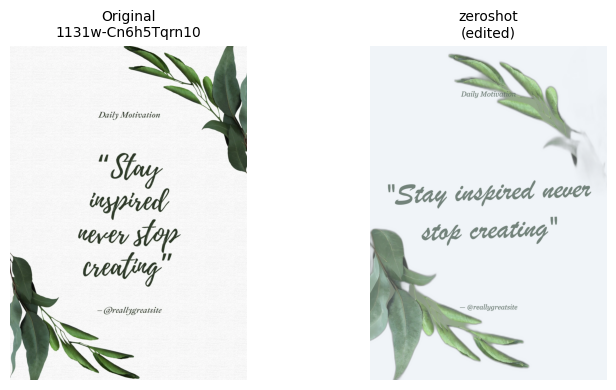

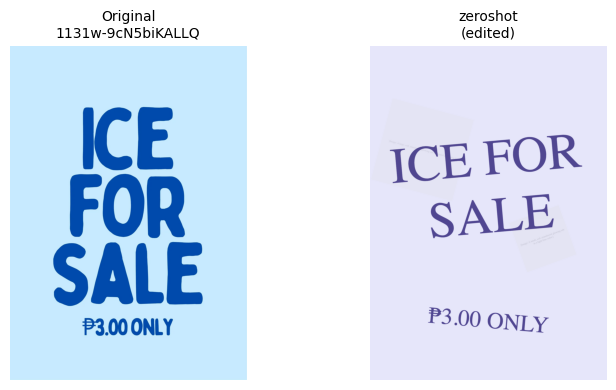

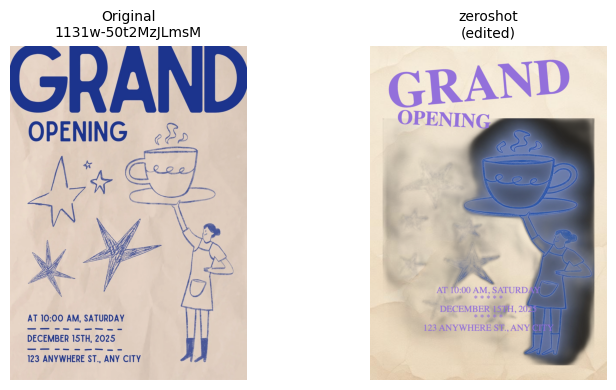

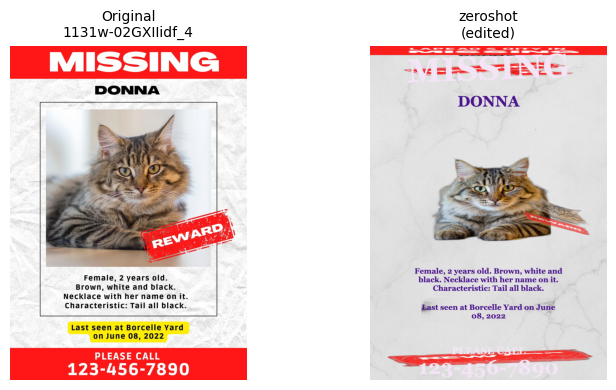

In [9]:
# Visualize rendered edits
import matplotlib.pyplot as plt
from PIL import Image

successful_results = results_df[results_df['status'] == 'success']

if len(successful_results) > 0:
    # Group by template_id to show all agent edits for each template
    for template_id in successful_results['template_id'].unique():
        template_results = successful_results[successful_results['template_id'] == template_id]
        
        # Load original for comparison
        original_spec_path = specs_df[specs_df['template_id'] == template_id]['spec_path'].iloc[0]
        original_render_path = Path('../datasets/original') / f"{template_id}.webp"
        
        num_agents = len(template_results)
        fig, axes = plt.subplots(1, num_agents + 1, figsize=(4 * (num_agents + 1), 4))
        
        if num_agents == 0:
            axes = [axes]
        
        # Show original
        if original_render_path.exists():
            img = Image.open(original_render_path)
            axes[0].imshow(img)
            axes[0].set_title(f"Original\n{template_id}", fontsize=10)
            axes[0].axis('off')
        
        # Show each agent's edit
        for idx, (_, row) in enumerate(template_results.iterrows(), start=1):
            render_path = Path(row['render_path'])
            if render_path.exists():
                img = Image.open(render_path)
                axes[idx].imshow(img)
                axes[idx].set_title(f"{row['agent']}\n(edited)", fontsize=10)
                axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
else:
    print("No successful edits to visualize")

In [ ]:
# Aesthetic evaluation with Gemini 2.5 (concurrent)
from lib.ai import gemini_score_aesthetic
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

print("Running Gemini 2.5 aesthetic evaluation (concurrent)...")
print("=" * 80)

def score_design(result_row):
    """Score both original and edited versions of a design."""
    template_id = result_row['template_id']
    agent = result_row['agent']
    
    # Score original
    original_path = Path('../datasets/original') / f"{template_id}.webp"
    if original_path.exists():
        try:
            original_score = gemini_score_aesthetic(str(original_path))
        except Exception as e:
            print(f"✗ Error scoring original {template_id}: {e}")
            original_score = None
    else:
        original_score = None
    
    # Score edited version
    edited_path = Path(result_row['render_path'])
    try:
        edited_score = gemini_score_aesthetic(str(edited_path))
    except Exception as e:
        print(f"✗ Error scoring edited {template_id}/{agent}: {e}")
        edited_score = None
    
    # Calculate difference
    diff = edited_score - original_score if (original_score is not None and edited_score is not None) else None
    
    return {
        'template_id': template_id,
        'agent': agent,
        'original_score': original_score,
        'edited_score': edited_score,
        'diff': diff
    }

aesthetic_results = []
successful_results = results_df[results_df['status'] == 'success']

print(f"Scoring {len(successful_results)} designs concurrently...")
print()

# Execute scoring in parallel
with ThreadPoolExecutor(max_workers=10) as executor:
    futures = {
        executor.submit(score_design, row): row
        for _, row in successful_results.iterrows()
    }
    
    for future in as_completed(futures):
        row = futures[future]
        result = future.result()
        aesthetic_results.append(result)
        
        # Print progress
        status_icon = "✓"
        print(f"{status_icon} {result['template_id']} / {result['agent']}: ", end="")
        if result['original_score'] is not None:
            print(f"orig={result['original_score']:.0f}, edit={result['edited_score']:.0f}, Δ={result['diff']:+.0f}")
        else:
            print(f"orig=N/A, edit={result['edited_score']:.0f}")

# Create aesthetic scores dataframe
aesthetic_df = pd.DataFrame(aesthetic_results)

print()
print("=" * 80)
print("AESTHETIC EVALUATION SUMMARY")
print("=" * 80)
print()

# Overall stats
if len(aesthetic_df) > 0:
    valid_results = aesthetic_df[aesthetic_df['diff'].notna()]
    
    if len(valid_results) > 0:
        avg_original = valid_results['original_score'].mean()
        avg_edited = valid_results['edited_score'].mean()
        avg_diff = valid_results['diff'].mean()
        
        print(f"Average original score:  {avg_original:.1f}/100")
        print(f"Average edited score:    {avg_edited:.1f}/100")
        print(f"Average difference:      {avg_diff:+.1f}")
        print()
        
        # Count improvements vs. degradations
        improvements = len(valid_results[valid_results['diff'] > 0])
        degradations = len(valid_results[valid_results['diff'] < 0])
        neutral = len(valid_results[valid_results['diff'] == 0])
        
        print(f"Improvements:   {improvements}/{len(valid_results)} ({100*improvements/len(valid_results):.1f}%)")
        print(f"Degradations:   {degradations}/{len(valid_results)} ({100*degradations/len(valid_results):.1f}%)")
        print(f"Neutral:        {neutral}/{len(valid_results)} ({100*neutral/len(valid_results):.1f}%)")
        print()
        
        # Best and worst
        best = valid_results.loc[valid_results['diff'].idxmax()]
        worst = valid_results.loc[valid_results['diff'].idxmin()]
        
        print(f"Best improvement:  {best['template_id']} / {best['agent']} ({best['diff']:+.1f})")
        print(f"Worst degradation: {worst['template_id']} / {worst['agent']} ({worst['diff']:+.1f})")

aesthetic_df

In [ ]:
# Scatter plot: Original vs Edited aesthetic scores
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Color map for agents
agent_colors = {
    'zeroshot': '#1f77b4',  # blue
    'singleshot': '#ff7f0e',  # orange
    'direct_edit': '#2ca02c',  # green
    # Add more agents with distinct colors:
    # 'vqa_critic': '#d62728',  # red
    # 'another_agent': '#9467bd',  # purple
}

# Plot each edit as a point
for agent, color in agent_colors.items():
    agent_data = aesthetic_df[aesthetic_df['agent'] == agent]
    valid_data = agent_data[agent_data['original_score'].notna() & agent_data['edited_score'].notna()]
    
    if len(valid_data) > 0:
        ax.scatter(
            valid_data['original_score'],
            valid_data['edited_score'],
            color=color,
            label=agent,
            s=100,
            alpha=0.7,
            edgecolors='white',
            linewidth=1.5
        )

# Add y=x reference line (no change)
ax.plot([0, 100], [0, 100], 
        color='gray', 
        linestyle='--', 
        linewidth=2, 
        alpha=0.5,
        label='No change (y=x)')

# Styling
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel('Original Aesthetic Score', fontsize=12)
ax.set_ylabel('Edited Aesthetic Score', fontsize=12)
ax.set_title('Aesthetic Score: Original vs Edited\n(Above diagonal = improvement, Below = degradation)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', framealpha=0.9)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"\nPlot shows {len(aesthetic_df[aesthetic_df['original_score'].notna()])} edits")
print("• Points above diagonal = aesthetic improvement")
print("• Points below diagonal = aesthetic degradation")
print("• Points on diagonal = no change")